<a href="https://colab.research.google.com/github/yadavrishikesh/Masterclass-V2-2026/blob/main/module2/code/CNN_Lab_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lab: Image Classification with Neural Networks and CNNs
**Author:** Dr. Rishikesh Yadav / Vedant Vibhor

### Objectives
1. Understand images as numerical tensors (Refer Lecture: *Grayscale vs RGB*).
2. Build an MLP on flattened images and observe the **Parameter Explosion** (Refer Lecture: *Why not just flatten?*).
3. Manually calculate CNN output shapes using the lecture formula (Refer Lecture: *Key Hyperparameters in Convolution*).
4. Build a CNN and compare parameter efficiency and accuracy.
5. Perform Error Analysis (Confusion Matrix, Failure Analysis).
6. Implement advanced training strategies: **Batch Normalization**, **Dropout**, and **Early Stopping** (Refer Lecture: *Useful Strategies for Training*).

**Dataset:** [Fashion-MNIST](https://www.tensorflow.org/tutorials/keras/classification)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Dropout, Activation

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


---
## Part 1: Images as Tensors
Computers "read" images as arrays of numbers. A grayscale image is a 2D matrix $I \in \mathbb{R}^{H \times W}$. RGB images are 3D tensors $X \in \mathbb{R}^{H \times W \times 3}$.

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
class_names = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]

print("X_train shape:", X_train.shape)

X_train shape: (60000, 28, 28)


### Exercise 1: Tensor Anatomy
1. Looking at the shape `(60000, 28, 28)`, what does each number represent?
2. Is this grayscale or RGB?
3. What is the maximum possible value of a pixel in this raw dataset (before normalization)?

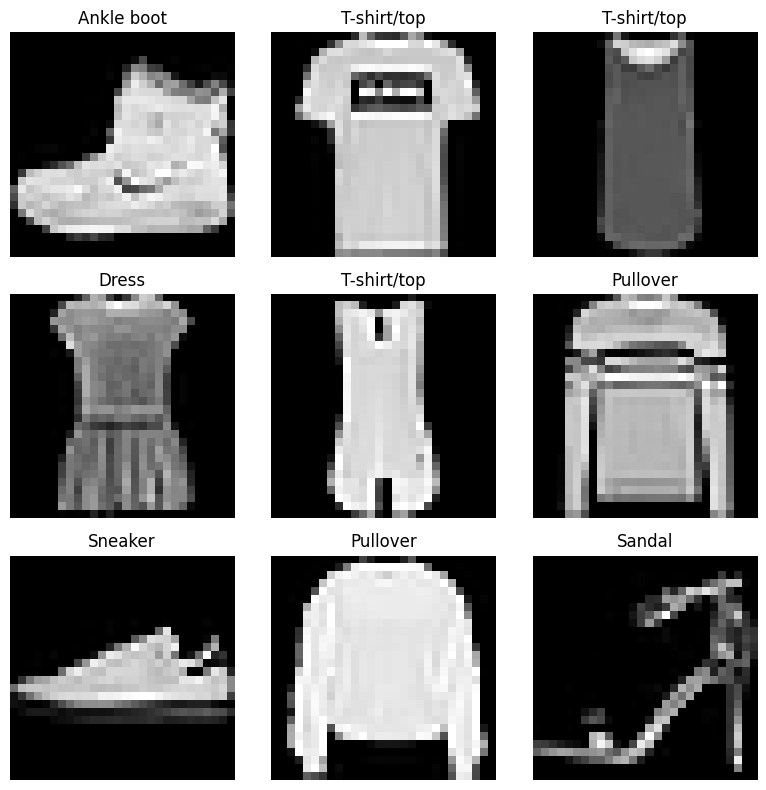

In [ ]:
# SOLUTION EXERCISE 1:
# 1. 60000 = number of images in training set. 28 = image height in pixels. 28 = image width in pixels.
# 2. Grayscale. If it were RGB, the shape would end in 3 (e.g., 60000, 28, 28, 3).
# 3. The maximum possible value is 255 (representing pure white). Minimum is 0 (pure black).

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Normalize pixel values to [0, 1] (Crucial for Neural Networks, as per lecture)
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Min pixel value:", X_train.min())
print("Max pixel value:", X_train.max())

Min pixel value: 0.0
Max pixel value: 1.0


---
## Part 2: The MLP Approach & Parameter Explosion
From the lecture: *"Flattening a $64 \times 64 \times 3$ image to $d = 12,288$. A Dense layer with 1,024 units has $\approx 12.6$ million parameters. No weight sharing, no explicit locality."*

In [ ]:
mlp = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

mlp.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Exercise 2: Manual Parameter Calculation
Using the lecture formula: `#params = (d * m) + m`
1. Calculate the parameters for the first Dense layer manually. ($d = 28 \times 28$, $m = 128$)
2. Does your calculation match the `Param #` in the summary?

In [ ]:
# SOLUTION EXERCISE 2:
# 1. d = 28 * 28 = 784. m = 128.
# Formula: (784 * 128) + 128 = 100,352 + 128 = 100,480.
# 2. Yes, the summary output exactly matches 100,480.

mlp.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_mlp = mlp.fit(X_train, y_train, epochs=10, validation_split=0.1, verbose=1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8235 - loss: 0.4971 - val_accuracy: 0.8333 - val_loss: 0.4405
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8651 - loss: 0.3705 - val_accuracy: 0.8735 - val_loss: 0.3440
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8777 - loss: 0.3342 - val_accuracy: 0.8752 - val_loss: 0.3389
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8863 - loss: 0.3101 - val_accuracy: 0.8768 - val_loss: 0.3362
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8932 - loss: 0.2913 - val_accuracy: 0.8785 - val_loss: 0.3370
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8964 - loss: 0.2803 - val_accuracy: 0.8855 - val_loss: 0.3230
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9006 - loss: 0.2663 - val_accuracy: 0.8827 - val_loss: 0.3299
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9033 - loss: 0.2576 - 

---
## Part 3: The CNN Approach & Shape Tracking
CNNs use convolutions: `#params = K * (k * k * C + 1)`. This is *independent of image width/height*.

Before running the code below, use the **Output Size Formula** from the lecture:
$$H' = \lfloor\frac{H + 2P - k}{S}\rfloor + 1$$

1. **Input:** (28, 28, 1)
2. **Conv2D(32, (3,3), padding='valid'):** $H' = \lfloor\frac{28 + 0 - 3}{1}\rfloor + 1 = ?$
3. **MaxPooling2D(2,2):** $H' = ?$
4. **Conv2D(64, (3,3), padding='valid'):** $H' = ?$
5. **MaxPooling2D(2,2):** $H' = ?$ (Note: 11/2 rounds down to 5)

In [ ]:
X_train_cnn = X_train[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

# Using Dense(16) as per our optimization to prove parameter efficiency
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1), padding='valid'),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu', padding='valid'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(10, activation='softmax')
])

cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │        25,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,602 (174.23 KB)

 Trainable params: 44,602 (174.23 KB)

 Non-trainable params: 0 (0.00 B)

### Exercise 3: Architecture Analysis
1. Check the `Output Shape` column. Did it match your manual calculations?
2. Look at the `Param #` for the first `conv2d` layer. Prove it using the formula: $K=32, k=3, C=1$.
3. **Discussion:** The lecture mentions `padding='same'` keeps the size identical ($H' = H$). If we changed the first layer to `padding='same'`, what would the output shape be?

In [ ]:
# SOLUTION EXERCISE 3:
# 1. (28,28,1) -> (26,26,32) -> (13,13,32) -> (11,11,64) -> (5,5,64). Yes, it matches perfectly.
# 2. K=32, k=3, C=1. Params = 32 * (3*3*1 + 1) = 32 * 10 = 320. Matches summary.
# 3. If we used padding='same', the output shape of the first Conv2D would remain (None, 28, 28, 32).

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_cnn = cnn.fit(X_train_cnn, y_train, epochs=10, validation_split=0.1, verbose=1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8014 - loss: 0.5601 - val_accuracy: 0.8512 - val_loss: 0.4185
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8698 - loss: 0.3648 - val_accuracy: 0.8723 - val_loss: 0.3602
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8862 - loss: 0.3167 - val_accuracy: 0.8875 - val_loss: 0.3129
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8981 - loss: 0.2825 - val_accuracy: 0.8887 - val_loss: 0.3072
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9062 - loss: 0.2582 - val_accuracy: 0.9008 - val_loss: 0.2764
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9154 - loss: 0.2372 - val_accuracy: 0.9047 - val_loss: 0.2720
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9190 - loss: 0.2228 - val_accuracy: 0.9055 - val_loss: 0.2614
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9241 - loss: 0.2073 

---
## Part 4: Training Diagnostics & Error Analysis

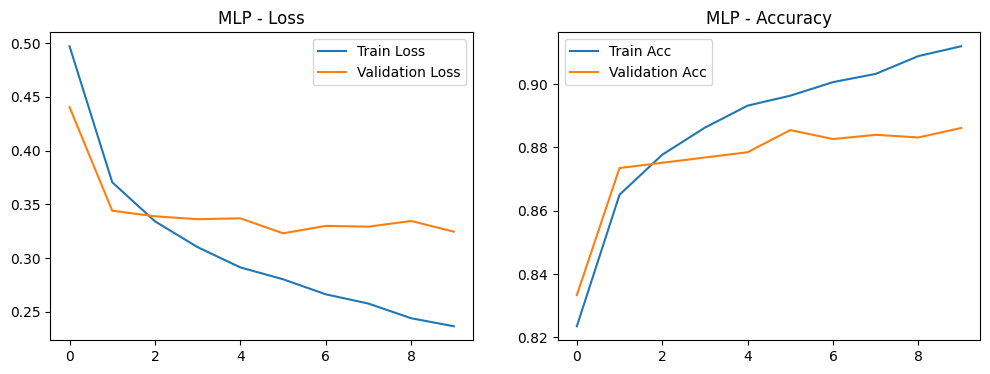

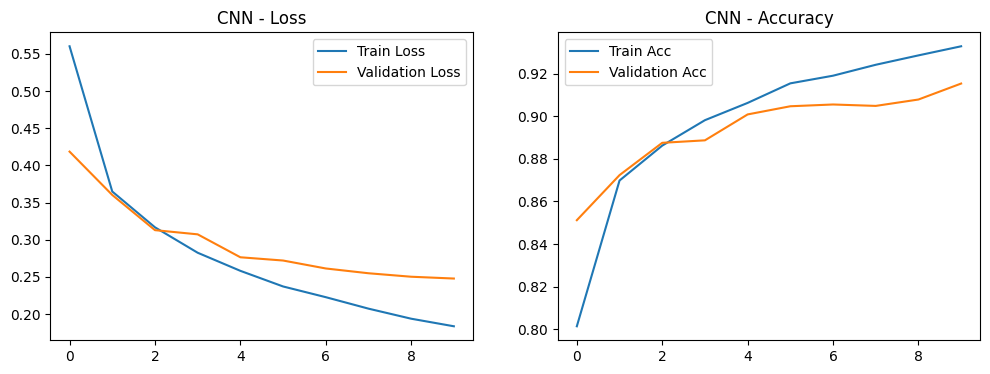

In [ ]:
def plot_learning_curve(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title(f'{title} - Loss'); axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='Train Acc')
    axes[1].plot(history.history['val_accuracy'], label='Validation Acc')
    axes[1].set_title(f'{title} - Accuracy'); axes[1].legend()
    plt.show()

plot_learning_curve(history_mlp, "MLP")
plot_learning_curve(history_cnn, "CNN")

### Exercise 4: Curve Interpretation
Look at the Validation Loss of the CNN. Does it start to increase while Training Loss decreases? This is the textbook definition of **overfitting**.

In [ ]:
# Baseline & Test Eval Comparison
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_flat, y_train)
baseline_acc = accuracy_score(y_test, dummy.predict(X_test_flat))

mlp_loss, mlp_acc = mlp.evaluate(X_test, y_test, verbose=0)
cnn_loss, cnn_acc = cnn.evaluate(X_test_cnn, y_test, verbose=0)

print(f"Baseline Accuracy: {baseline_acc:.4f}")
print(f"MLP Test Accuracy: {mlp_acc:.4f}")
print(f"CNN Test Accuracy: {cnn_acc:.4f}")

Baseline Accuracy: 0.1000
MLP Test Accuracy: 0.8812
CNN Test Accuracy: 0.9096


### Confusion Matrix Analysis

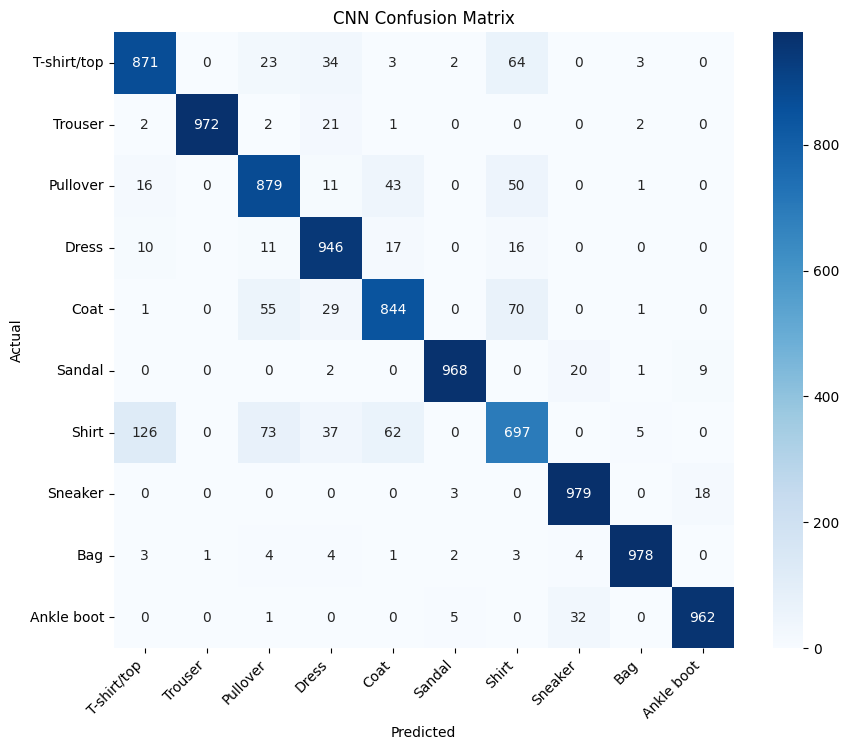

In [ ]:
cnn_pred = cnn.predict(X_test_cnn, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, cnn_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Exercise: Which classes are most frequently confused?
While the heatmap is useful, a Classification Report gives us exact metrics (Precision/Recall) per class.

In [ ]:
# TODO: Print the classification report for the CNN predictions
print(classification_report(y_test, cnn_pred, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.87      0.86      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover       0.84      0.88      0.86      1000
       Dress       0.87      0.95      0.91      1000
        Coat       0.87      0.84      0.86      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.77      0.70      0.73      1000
     Sneaker       0.95      0.98      0.96      1000
         Bag       0.99      0.98      0.98      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



### Failure Analysis

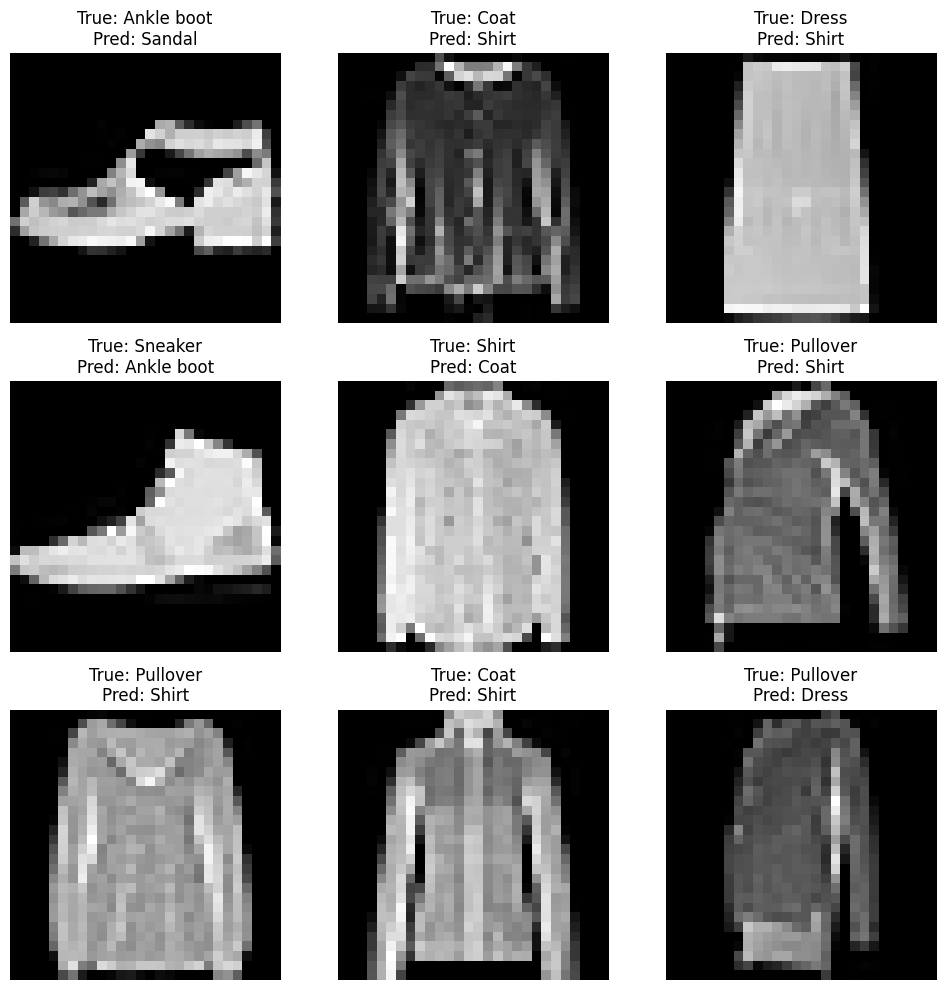

In [ ]:
wrong = np.where(cnn_pred != y_test)[0]

plt.figure(figsize=(10,10))
for i, idx in enumerate(wrong[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[idx], cmap="gray")
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[cnn_pred[idx]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Reflection Questions
1. Are the mistakes the model makes reasonable?
2. Would a human confuse these classes (e.g., Shirt vs T-shirt/top, Pullover vs Coat)?

In [ ]:
# SOLUTION REFLECTIONS:


---
## Part 5: Advanced CNN (Regularization Strategies)
The lecture introduced three key strategies to fix the overfitting we just observed:
1. **Batch Normalization:** Stabilizes activations. Applied *after* Conv, *before* Activation (`Conv -> BatchNorm -> ReLU`).
2. **Dropout:** Randomly deactivates neurons to prevent overfitting.
3. **Early Stopping:** Stops training when validation loss stops improving.

In [ ]:
# Define the Early Stopping callback
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,            # Wait 3 epochs without improvement before stopping
    restore_best_weights=True # Keep the best model weights, not the last ones
)

In [ ]:
# TODO: Build an Advanced CNN
advanced_cnn = Sequential([
    # Layer 1
    Conv2D(32, (3,3), padding='same', input_shape=(28,28,1)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),

    # Layer 2
    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(10, activation='softmax')
])

advanced_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │        50,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,562 (271.73 KB)

 Trainable params: 69,370 (270.98 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# TODO: Compile the advanced_cnn
advanced_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# TODO: Train the advanced_cnn for 50 epochs.
history_adv = advanced_cnn.fit(
    X_train_cnn, y_train,
    epochs=50,
    validation_split=0.1,
    callbacks=[early_stop], # Crucial Step!
    verbose=1
)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.8055 - loss: 0.5348 - val_accuracy: 0.8650 - val_loss: 0.3744
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8793 - loss: 0.3375 - val_accuracy: 0.8940 - val_loss: 0.3001
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8945 - loss: 0.2970 - val_accuracy: 0.8882 - val_loss: 0.3028
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9027 - loss: 0.2711 - val_accuracy: 0.9095 - val_loss: 0.2509
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9088 - loss: 0.2529 - val_accuracy: 0.8980 - val_loss: 0.2806
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9121 - loss: 0.2409 - val_accuracy: 0.9198 - val_loss: 0.2354
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9182 - loss: 0.2259 - val_accuracy: 0.9057 - val_loss: 0.2640
Epoch 8/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9211 - loss: 0.2179 

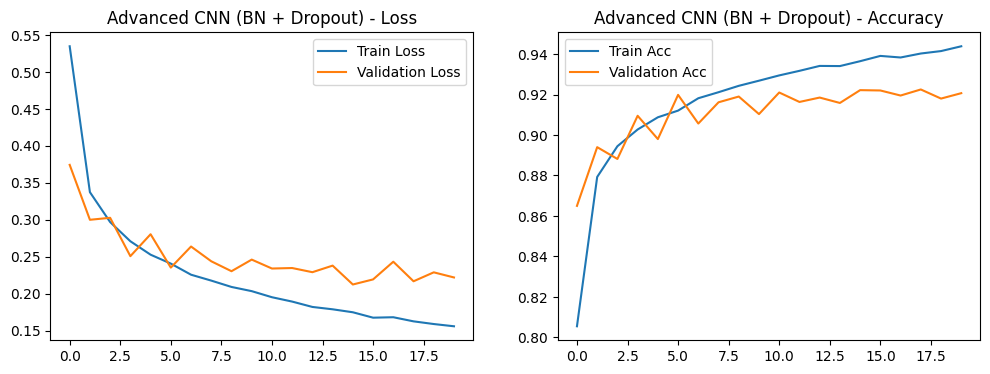

Advanced CNN Test Accuracy: 0.9187


In [ ]:
# Plot the learning curve for the advanced CNN
plot_learning_curve(history_adv, "Advanced CNN (BN + Dropout)")

# Evaluate
adv_loss, adv_acc = advanced_cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Advanced CNN Test Accuracy: {adv_acc:.4f}")

### Final Model Comparison

In [ ]:
final_comparison = pd.DataFrame({
    "Model": ["Baseline (Guess Most Frequent)", "Standard MLP", "Standard CNN", "Advanced CNN (+Reg)"],
    "Test Accuracy": [baseline_acc, mlp_acc, cnn_acc, adv_acc],
    "Total Parameters": [0, mlp.count_params(), cnn.count_params(), advanced_cnn.count_params()]
})

# Sort by accuracy to clearly see the winner
final_comparison.sort_values(by="Test Accuracy", ascending=False)

,Model,Test Accuracy,Total Parameters
3,Advanced CNN (+Reg),0.9187,69562
2,Standard CNN,0.9096,44602
1,Standard MLP,0.8812,109386
0,Baseline (Guess Most Frequent),0.1000,0


---
## Bonus: Visualizing Learned Filters
The lecture states: *"Convolution layer: learn local feature detectors (edges, textures, parts)."*

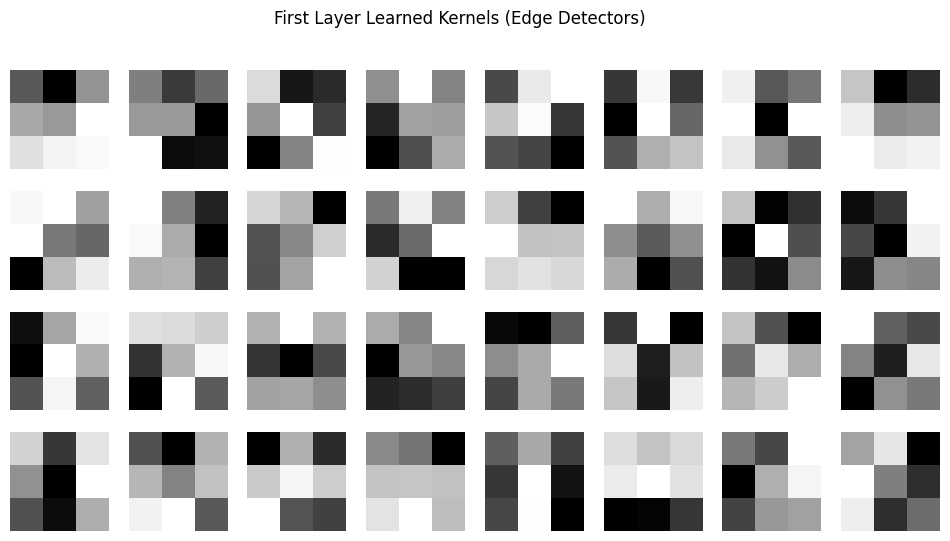

In [ ]:
# Extract filters from the first Conv2D layer of the standard CNN
filters, biases = cnn.layers[0].get_weights()

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < 32:
        ax.imshow(filters[:, :, 0, i], cmap='gray')
    ax.axis('off')
plt.suptitle("First Layer Learned Kernels (Edge Detectors)")
plt.show()

## Bonus: Feature Map Visualization
What does the network "see" when it looks at an image?

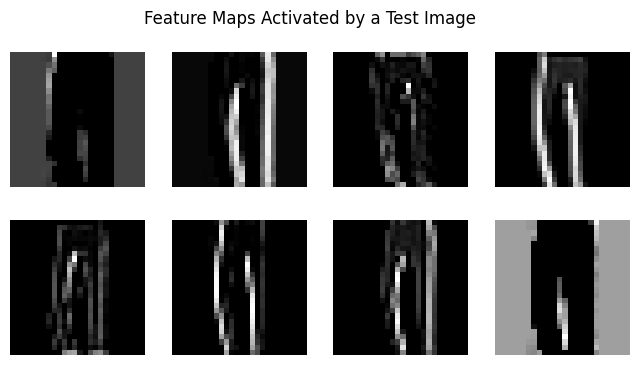

In [ ]:
# Create a model that outputs the feature maps of the first layer
inp = tf.keras.Input(shape=(28, 28, 1))
out = cnn.layers[0](inp)
feature_model = tf.keras.Model(inputs=inp, outputs=out)

feature_maps = feature_model.predict(X_test_cnn[2:3], verbose=0)

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[0,:,:,i], cmap="gray")
    ax.axis("off")
plt.suptitle("Feature Maps Activated by a Test Image")
plt.show()

### Key Takeaways
- Images are $H \times W \times C$ tensors.
- MLPs destroy spatial structure and suffer from parameter explosion ($d \times m$).
- CNNs preserve spatial structure via local connectivity and weight sharing ($K \times (k^2C + 1)$).
- You can mathematically predict the output shape of a CNN layer using the formula.
- **Batch Normalization**, **Dropout**, and **Early Stopping** are essential tools to combat overfitting and stabilize deep networks.